In [1]:
import os
import json
import re
import pandas as pd

pd.options.display.max_columns = None

In [2]:
def extract_json(response: str):
    """Extract JSON content from a formatted string."""
    match = re.search(r"```json\s*(.*?)\s*```", response, re.DOTALL)
    if match:
        json_str = match.group(1)
    else:
        json_str = response.strip('```json').strip('```')
    
    try:
        return json.loads(json_str)
    except json.JSONDecodeError as e:
        print(f"Chyba při dekódování JSON: {e}")
        return None

In [3]:
def process_txt_files(folder_path, prefix):
    """Zpracuje všechny txt soubory začínající prefixem (např. 'bank_part') ve složce a vrátí Pandas DataFrame."""
    all_data = []
    
    # Get files with prefix and end with .txt
    files = [f for f in os.listdir(folder_path) if f.startswith(prefix) and f.endswith(".txt")]
    
    # Order by number
    files.sort(key=lambda x: int(re.search(r'chunk(\d+)', x).group(1)))
    
    for filename in files:
        file_path = os.path.join(folder_path, filename)
        with open(file_path, "r", encoding="utf-8") as file:
            for line in file:
                try:
                    json_obj = json.loads(line.strip())
                    content_str = json_obj.get("response", {}).get("body", {}).get("choices", [{}])[0].get("message", {}).get("content", "")
                    extracted_json = extract_json(content_str)
                    
                    if extracted_json:
                        row = {"id": json_obj["id"], "custom_id": json_obj["custom_id"]}
                        for feature in extracted_json.get("features", []):
                            row[feature["feature_name"]] = feature["answer"]
                        
                        all_data.append(row)
                except json.JSONDecodeError:
                    print(f"Chyba dekódování JSON v souboru {filename}")

    df = pd.DataFrame(all_data)
    return df

In [4]:
# Použití skriptu
folder_path = "../../data/outputs/hate_speech"
df = process_txt_files(folder_path, "hate")

# Zobrazení výsledného dataframe
df

,id,custom_id,Presence of Racial Slurs,Mention of Ethnic Groups,Sentiment Polarity,Use of Violent Language,Presence of Hate Symbols,Use of Sarcasm,Text Length,Use of Expletives,Grammatical Errors,Use of First-Person Pronouns,Use of Second-Person Pronouns,Use of Third-Person Pronouns,Presence of Questions,Presence of Negations,Use of Hyperbolic Language,Presence of Emotive Language,Use of Metaphors,Presence of Direct Quotes,Use of Capitalization for Emphasis,Presence of Lists
0,batch_req_67c67638a93c8190bb71b26f520c368e,0,No,No,Neutral,No,No,No,Medium,No,No,No,No,Yes,No,No,No,No,No,No,No,No
1,batch_req_67c67638c37081909ae7b84b911fb321,1,No,No,Neutral,No,No,No,Medium,No,No,Yes,Yes,No,No,No,No,No,No,No,No,No
2,batch_req_67c67638d6d0819096c81e188903afc6,2,No,No,Neutral,No,No,No,Short,No,No,No,No,No,No,No,No,No,No,No,No,No
3,batch_req_67c67638eb008190a70be21f3e5b601d,3,No,Yes,Negative,Yes,No,No,Long,No,No,No,No,Yes,No,No,Yes,Yes,No,No,Yes,No
4,batch_req_67c67638fa70819095a705d14e5438b7,4,No,No,Neutral,No,No,No,Short,No,No,No,Yes,No,No,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10939,batch_req_67d2abc78b68819090af09f9002a822c,10939,No,Yes,Negative,No,No,Yes,Medium,No,No,Yes,No,Yes,No,Yes,No,Yes,No,Yes,No,No
10940,batch_req_67d2abc7b7788190a2ee342880ae46d0,10940,No,Yes,Negative,No,No,No,Short,No,No,Yes,No,No,No,No,No,Yes,No,No,No,No
10941,batch_req_67d2abc7d72c819096a1c31b6a9e9153,10941,Yes,No,Negative,No,No,Yes,Medium,No,No,No,No,No,No,No,Yes,Yes,No,No,No,Yes
10942,batch_req_67d2abc809588190bd83a4ac1466ab64,10942,No,Yes,Neutral,No,No,No,Medium,No,No,Yes,No,Yes,Yes,Yes,No,No,No,No,No,No


# Merge with target

In [5]:
from datasets import load_dataset

data_load = load_dataset("odegiber/hate_speech18")

C:\Users\vojta\miniconda3\envs\llm-features\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
load_dataset = pd.DataFrame(data_load['train'])
#load_dataset_test = pd.DataFrame(data_load['test'])
#load_dataset = pd.concat([load_dataset, load_dataset_test], axis=0)
df['label'] = list(load_dataset['label'])[:len(df)]

In [7]:
df

,id,custom_id,Presence of Racial Slurs,Mention of Ethnic Groups,Sentiment Polarity,Use of Violent Language,Presence of Hate Symbols,Use of Sarcasm,Text Length,Use of Expletives,Grammatical Errors,Use of First-Person Pronouns,Use of Second-Person Pronouns,Use of Third-Person Pronouns,Presence of Questions,Presence of Negations,Use of Hyperbolic Language,Presence of Emotive Language,Use of Metaphors,Presence of Direct Quotes,Use of Capitalization for Emphasis,Presence of Lists,label
0,batch_req_67c67638a93c8190bb71b26f520c368e,0,No,No,Neutral,No,No,No,Medium,No,No,No,No,Yes,No,No,No,No,No,No,No,No,0
1,batch_req_67c67638c37081909ae7b84b911fb321,1,No,No,Neutral,No,No,No,Medium,No,No,Yes,Yes,No,No,No,No,No,No,No,No,No,0
2,batch_req_67c67638d6d0819096c81e188903afc6,2,No,No,Neutral,No,No,No,Short,No,No,No,No,No,No,No,No,No,No,No,No,No,0
3,batch_req_67c67638eb008190a70be21f3e5b601d,3,No,Yes,Negative,Yes,No,No,Long,No,No,No,No,Yes,No,No,Yes,Yes,No,No,Yes,No,1
4,batch_req_67c67638fa70819095a705d14e5438b7,4,No,No,Neutral,No,No,No,Short,No,No,No,Yes,No,No,No,No,No,No,No,No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10939,batch_req_67d2abc78b68819090af09f9002a822c,10939,No,Yes,Negative,No,No,Yes,Medium,No,No,Yes,No,Yes,No,Yes,No,Yes,No,Yes,No,No,0
10940,batch_req_67d2abc7b7788190a2ee342880ae46d0,10940,No,Yes,Negative,No,No,No,Short,No,No,Yes,No,No,No,No,No,Yes,No,No,No,No,0
10941,batch_req_67d2abc7d72c819096a1c31b6a9e9153,10941,Yes,No,Negative,No,No,Yes,Medium,No,No,No,No,No,No,No,Yes,Yes,No,No,No,Yes,0
10942,batch_req_67d2abc809588190bd83a4ac1466ab64,10942,No,Yes,Neutral,No,No,No,Medium,No,No,Yes,No,Yes,Yes,Yes,No,No,No,No,No,No,1


In [8]:
df = df.drop(columns=["id", "custom_id"])
data = pd.get_dummies( 
        df, sparse=False, prefix_sep='_', drop_first=True
    )

In [9]:
data

,label,Presence of Racial Slurs_Yes,Mention of Ethnic Groups_Yes,Sentiment Polarity_Neutral,Sentiment Polarity_Positive,Use of Violent Language_Yes,Presence of Hate Symbols_Yes,Use of Sarcasm_Yes,Text Length_Medium,Text Length_Short,Use of Expletives_Yes,Grammatical Errors_Yes,Use of First-Person Pronouns_Yes,Use of Second-Person Pronouns_Yes,Use of Third-Person Pronouns_Yes,Presence of Questions_Yes,Presence of Negations_Yes,Use of Hyperbolic Language_Yes,Presence of Emotive Language_Yes,Use of Metaphors_Yes,Presence of Direct Quotes_Yes,Use of Capitalization for Emphasis_Yes,Presence of Lists_Yes
0,0,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,0,False,False,True,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False
2,0,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3,1,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,True,False
4,0,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10939,0,False,True,False,False,False,False,True,True,False,False,False,True,False,True,False,True,False,True,False,True,False,False
10940,0,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False
10941,0,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,True,False,False,False,True
10942,1,False,True,True,False,False,False,False,True,False,False,False,True,False,True,True,True,False,False,False,False,False,False


In [10]:
# 1) Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 2) Příprava feature matic X a cílové proměnné y
X = data.drop(columns=["label"])
y = data["label"]
#categorical_columns = X.select_dtypes(include=["object"]).columns
#X = df.drop(columns=categorical_columns)

# 3) Rozdělení na trénovací a testovací sadu
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)  # stratify, pokud je to klasifikace s nerovnoměrnými třídami

# ----------------------------------------------------------------
# 4) Definice modelu RandomForestClassifier
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# 5) Nastavení rozsahu parametrů pro RandomizedSearchCV
param_grid = {
    "n_estimators": [50, 100, 200],       # Počet stromů v lese
    "max_depth": [3, 5, 10, None],        # Maximální hloubka stromu
    "min_samples_split": [2, 5, 10],      # Minimální počet vzorků pro split
    "min_samples_leaf": [1, 2, 5],        # Minimální počet vzorků v listu
}

# 6) Konfigurace RandomizedSearchCV (n_iter a cv lze upravit dle potřeby)
random_search = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=5,                  # 5-fold cross-validace
    scoring="accuracy",    # metrika, dle které se bude model porovnávat
    n_jobs=-1,             # využití všech CPU jader pro rychlejší výpočet
    verbose=1
)

# 7) Trénink modelu s vyhledáváním nejlepších hyperparametrů
random_search.fit(X_train, y_train)

# 8) Vypsání nejlepších parametrů a skóre
print("Nejlepší parametry:", random_search.best_params_)
print("Nejlepší skóre na trénovací cross-validaci:", random_search.best_score_)

# 9) Ověření na testovací sadě
best_model = random_search.best_estimator_  # získáme nejlepší nalezený model
y_pred = best_model.predict(X_test)

# 10) Vyhodnocení
print("Přesnost na testu:", accuracy_score(y_test, y_pred))
print("Classification report na testu:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Nejlepší parametry: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Nejlepší skóre na trénovací cross-validaci: 0.6583666476299257
Přesnost na testu: 0.6509821836455002
Classification report na testu:
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1901
           1       0.40      0.55      0.46       239
           2       0.03      0.60      0.06        15
           3       0.05      0.26      0.09        34

    accuracy                           0.65      2189
   macro avg       0.35      0.52      0.35      2189
weighted avg       0.84      0.65      0.72      2189



In [43]:
grid_rfc = {
    'max_depth': [10, 20, 30, 40, 50, None],
    'max_features': ['log2', 'sqrt', 30],
    'min_samples_leaf': [30, 40, 50, 60, 70, 90],
    'min_samples_split': [20, 30, 50, 60, 90],
    'n_estimators': [ 100, 200, 400, 1000]}

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import recall_score,f1_score, precision_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV
def train_gbc(X_train, y_train, X_test, y_test, metric = None):
    gbc = GradientBoostingClassifier()
    gbc_grid = RandomizedSearchCV(estimator = gbc, n_iter=1000 , param_distributions = grid_rfc, cv = 5, verbose=3, n_jobs = -1, scoring=metric, random_state=42)
    gbc_grid.fit(X_train, y_train)
    best = gbc_grid.best_estimator_

    y_pred = best.predict(X_test)
    display(f"Best params: {gbc_grid.best_params_}")
    display(f"Gradient Boosting Classifier Accuracy score: {accuracy_score(y_test, y_pred)}")
    display(f"Gradient Boosting Classifier Recall score: {recall_score(y_test, y_pred, average='macro')}")
    display(f"Gradient Boosting Classifier F1 score: {f1_score(y_test,  y_pred, average='macro')}")
    display(f"Gradient Boosting Classifier Precision score: {precision_score(y_test, y_pred, average='macro')}")
    # get_conf_matrix(y_test, y_pred)


    result = permutation_importance(
        best, X_test, y_test, n_repeats=30, random_state=42, n_jobs=2
    )
    forest_importances = pd.Series(result.importances_mean, index=X_train.columns)
    forest_importances = forest_importances.sort_values(ascending=False)[:16]
    display(forest_importances)

    fig, ax = plt.subplots()
    forest_importances.plot.bar(ax=ax)
    ax.set_title("Feature importances using permutation on full model")
    ax.set_ylabel("Mean accuracy decrease")
    fig.tight_layout()
    plt.show()

    return best

best = train_gbc(X_train, y_train, X_test, y_test, 'recall_macro')


Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


KeyboardInterrupt: 

In [62]:
import shap
# Plot SHAP summary plot
explainer = shap.Explainer(best.predict, X_train)
shap_values = explainer.shap_values(X_train)

PermutationExplainer explainer:   6%|▌         | 522/8755 [01:20<24:08,  5.68it/s]

KeyboardInterrupt



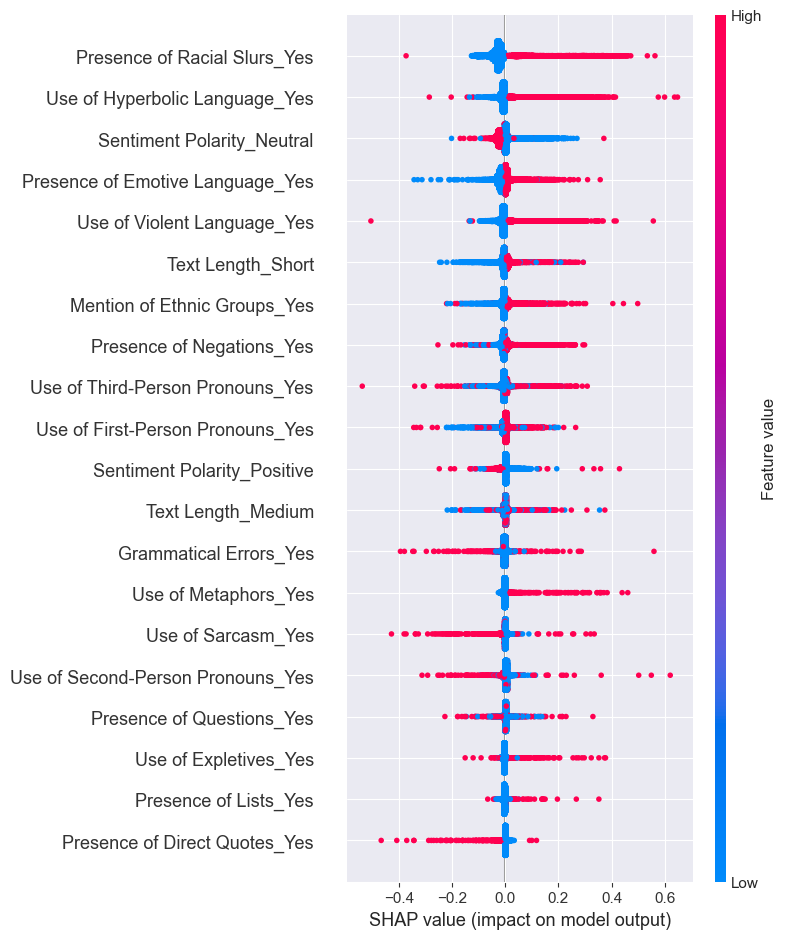

In [41]:
shap.summary_plot(
    shap_values,  # Use the SHAP values for class 0 - no hate speech
    X_train,
    class_names=best.classes_,
    max_display=20
)

In [12]:
best_model

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [14]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train, approximate=True)

In [15]:
shap_values

array([[[ 2.01249905e-02, -5.03465458e-02,  2.48488855e-02,
          5.37266978e-03],
        [ 6.34899061e-02,  4.52191996e-02, -2.33886837e-01,
          1.25177731e-01],
        [ 3.83863191e-02, -9.38801607e-02,  4.69667201e-02,
          8.52712140e-03],
        ...,
        [ 9.75233698e-04, -1.99972629e-03,  1.69036772e-03,
         -6.65875131e-04],
        [ 1.45572373e-03, -1.16127663e-03, -1.80129310e-03,
          1.50684600e-03],
        [-6.47377360e-03, -5.07407034e-03,  4.51005548e-03,
          7.03778846e-03]],

       [[ 1.37322596e-02, -3.27337671e-02,  1.70300553e-02,
          1.97145223e-03],
        [ 1.56526684e-02, -2.33391807e-02,  5.28234838e-02,
         -4.51369715e-02],
        [-6.24316800e-04, -6.84528102e-02,  8.30115923e-02,
         -1.39344654e-02],
        ...,
        [-1.13878702e-03, -5.07730240e-04,  7.24079800e-03,
         -5.59428074e-03],
        [ 8.06742882e-03, -3.70219571e-04,  3.86862474e-03,
         -1.15658340e-02],
        [-4.748

In [16]:
print("Number of features in X_train:", len(X_train.columns))
print("Length of shap_values for sample 0 in class 0:", len(shap_values[0][0]))


Number of features in X_train: 22
Length of shap_values for sample 0 in class 0: 4


In [57]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test, approximate=True)

PermutationExplainer explainer: 2190it [07:22,  4.79it/s]                          


ValueError: axes don't match array

In [61]:
shap.summary_plot(
    shap_values[:, :, 1],  # Use the SHAP values for class 0 - no hate speech
    X_test,
    class_names=best_model.classes_,
    max_display=20
)


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

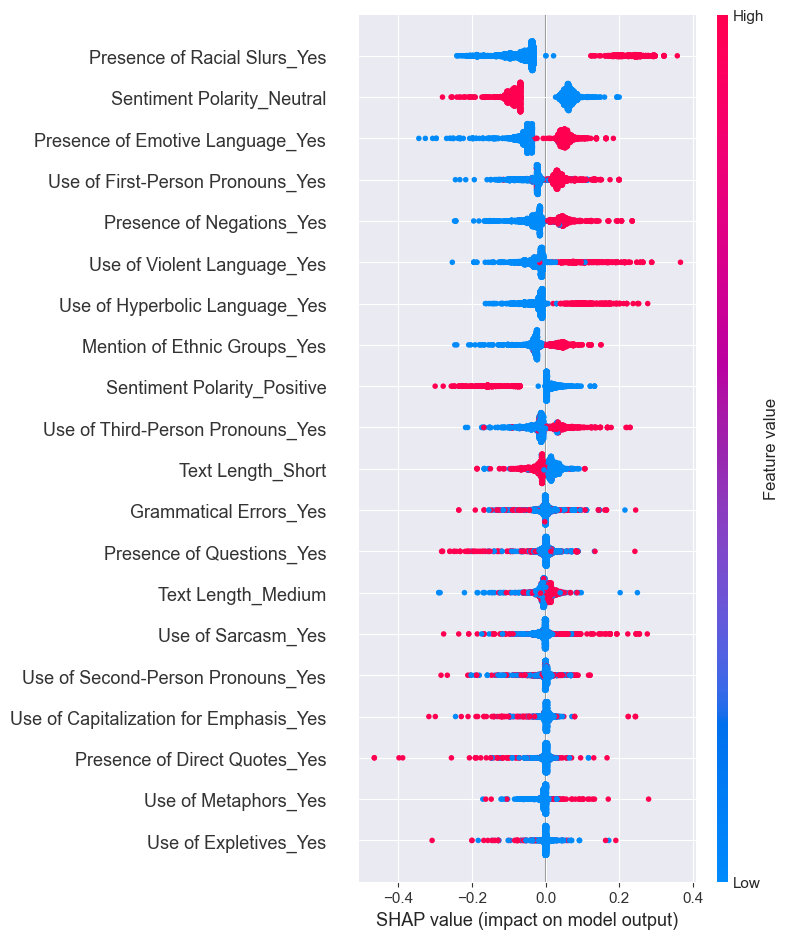

In [54]:
import matplotlib.pyplot as plt

# Create figure with specific size

plt.figure(figsize=(12, 8))

# Create SHAP summary plot
shap.summary_plot(
    shap_values[:, :, 1],  # Use the SHAP values for class 0 - no hate speech
    X_test,
    class_names=best_model.classes_,
    max_display=20,
    show=False, color=plt.get_cmap('coolwarm'))  # Don't show yet


# Save the figure with high resolution
plt.savefig('shap_summary_class1_hate.pdf', bbox_inches='tight', facecolor='white')

# Now display the plot (optional)
plt.show()

In [20]:
def shap_values_to_list(shap_values, model):
    shap_as_list=[]
    for i in range(len(model.classes_)):
        shap_as_list.append(shap_values[:,:,i])
    return shap_as_list

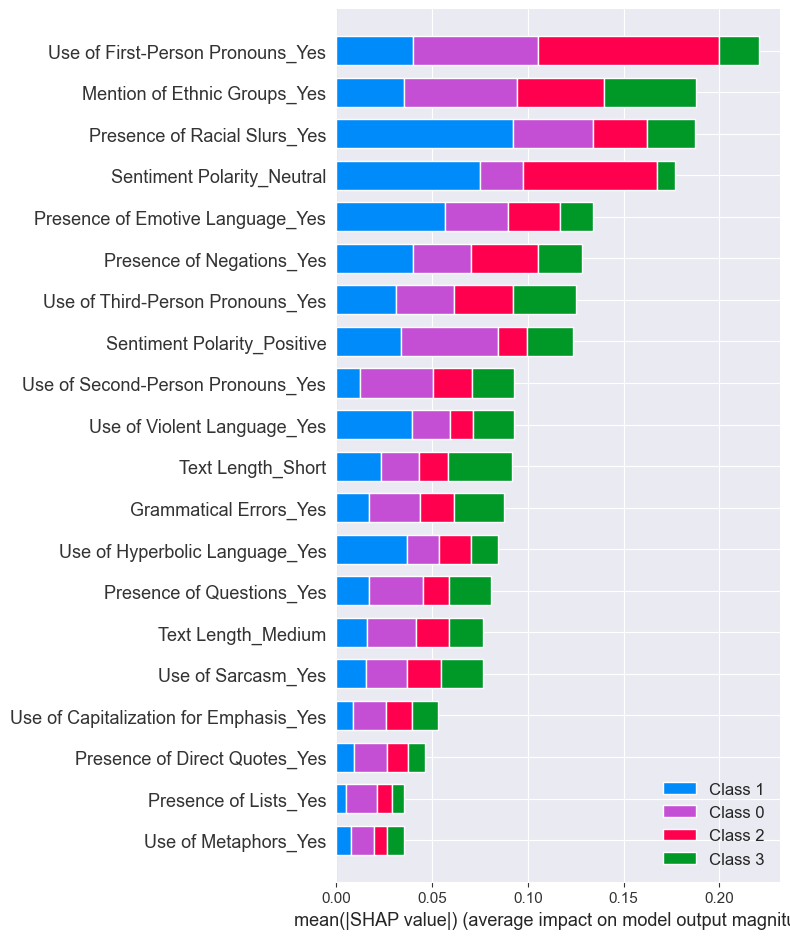

In [33]:
wshap_as_list = shap_values_to_list(shap_values, best_model)
import matplotlib
# matplotlib.rcParams['shap.summary_plot.cmap'] = 'viridis'
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_as_list,
    X_train,
    plot_type="bar",
    cmap="viridis"
)
# plt.savefig('shap_summary_custom_color.pdf', bbox_inches='tight')
